In [2]:
import requests
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [5]:
img_path = "infer/test_imgs/image.png"

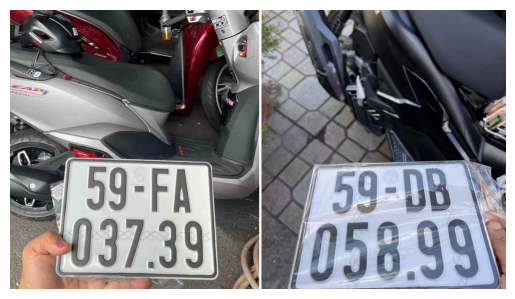

In [6]:
img = cv2.imread(img_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img_rgb)
plt.axis("off")
plt.show()

In [7]:
url = "http://192.168.28.32:8002/api/infer"

files = {
    "file": open(img_path, "rb")
}

response = requests.post(url, files=files)

print(response.status_code)
print(response.json())

200
{'records': [{'text': '59FA03739', 'bbox': [134, 382, 525, 694]}, {'text': '59DB05899', 'bbox': [759, 391, 1243, 718]}]}


In [ ]:
data = response.json()

for item in data["records"]:
    print("Plate:", item["text"])
    print("BBox:", item["bbox"])
    print("-" * 30)

Plate: 59FA03739
BBox: [134, 382, 525, 694]
------------------------------
Plate: 59DB05899
BBox: [759, 391, 1243, 718]
------------------------------


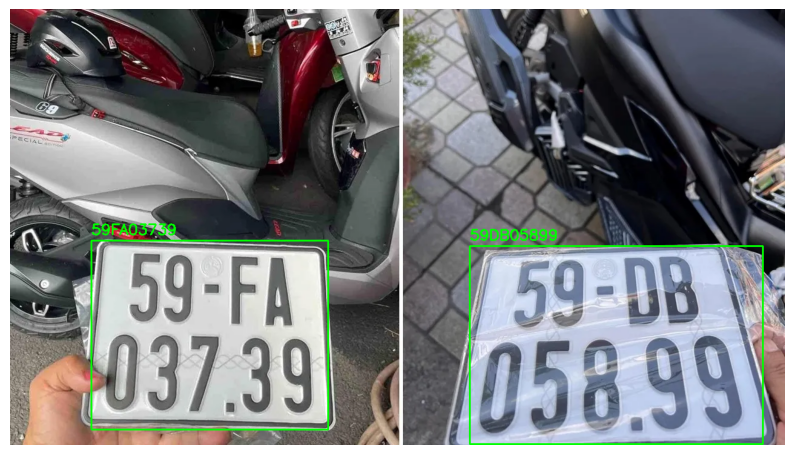

In [13]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread(img_path)

for item in data["records"]:
    x1, y1, x2, y2 = item["bbox"]
    text = item["text"]

    # draw bbox
    cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)

    # draw label
    cv2.putText(
        img,
        text,
        (x1, y1 - 10),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.8,
        (0, 255, 0),
        2
    )

# convert BGR → RGB for display
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 10))
plt.imshow(img_rgb)
plt.axis("off")
plt.show()